# Component 1 · Task 1 — Classical Harmonic Oscillator: Energy and Phase Space
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** State the classical energy function, derive the equations of motion from Hamilton's equations, and visualize the energy landscape in phase space.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Use a clean style consistent with publication figures
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 120,
})

## (a) Classical Energy Function

The classical energy (Hamiltonian) of a 1D harmonic oscillator is:

$$E(x, p) = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2$$

- First term: **kinetic energy** $T = p^2 / 2m$
- Second term: **potential energy** $V = \frac{1}{2}m\omega^2 x^2$ (parabolic well)

This function is also the Hamiltonian $H(x, p)$ that generates the dynamics.

In [19]:
# ── System parameters ────────────────────────────────────────────────────────
m   = 1.0   # mass (dimensionless units)
omega = 1.0  # angular frequency (dimensionless units)
hbar = 1.0   # set hbar=1 for dimensionless units (used later in quantum component)

def energy(x, p, m=m, omega=omega):
    """Classical harmonic oscillator energy E(x, p) = p²/2m + ½mω²x²."""
    kinetic   = p**2 / (2 * m)
    potential = 0.5 * m * omega**2 * x**2
    return kinetic + potential

print("Energy function defined: E(x,p) = p²/(2m) + ½mω²x²")
print(f"Parameters: m={m}, ω={omega}")
print(f"Check E(1,0) = {energy(1,0):.3f}  (expected: 0.500)")
print(f"Check E(0,1) = {energy(0,1):.3f}  (expected: 0.500)")

Energy function defined: E(x,p) = p²/(2m) + ½mω²x²
Parameters: m=1.0, ω=1.0
Check E(1,0) = 0.500  (expected: 0.500)
Check E(0,1) = 0.500  (expected: 0.500)


## (b) Equations of Motion via Hamilton's Equations

Hamilton's equations are:
$$\dot{x} = \frac{\partial H}{\partial p} = \frac{p}{m}, \qquad \dot{p} = -\frac{\partial H}{\partial x} = -m\omega^2 x$$

Differentiating the first equation and substituting the second:
$$\ddot{x} = \frac{\dot{p}}{m} = -\omega^2 x$$

This is the familiar **simple harmonic oscillator ODE**. Its general solution is:
$$x(t) = A\cos(\omega t + \phi), \qquad p(t) = -mA\omega\sin(\omega t + \phi)$$
where $A$ and $\phi$ are set by initial conditions.

In [20]:
def analytic_trajectory(t, x0, p0, m=m, omega=omega):
    """
    Analytic solution to Hamilton's equations for the harmonic oscillator.
    Returns (x(t), p(t)) given initial conditions (x0, p0).
    Derived from: x(t) = x0*cos(ωt) + (p0/mω)*sin(ωt)
    """
    x_t = x0 * np.cos(omega * t) + (p0 / (m * omega)) * np.sin(omega * t)
    p_t = -m * omega * x0 * np.sin(omega * t) + p0 * np.cos(omega * t)
    return x_t, p_t

print("Analytic solution defined.")
print("x(t) = x0·cos(ωt) + (p0/mω)·sin(ωt)")
print("p(t) = -mω·x0·sin(ωt) + p0·cos(ωt)")

# Quick sanity check: energy must be conserved along trajectory
t_test = np.linspace(0, 10, 500)
x0_test, p0_test = 1.5, 0.5
x_traj, p_traj = analytic_trajectory(t_test, x0_test, p0_test)
E_along_traj = energy(x_traj, p_traj)
print(f"\nEnergy conservation check (should be constant):")
print(f"  E_min={E_along_traj.min():.6f}, E_max={E_along_traj.max():.6f} ✓")

Analytic solution defined.
x(t) = x0·cos(ωt) + (p0/mω)·sin(ωt)
p(t) = -mω·x0·sin(ωt) + p0·cos(ωt)

Energy conservation check (should be constant):
  E_min=1.250000, E_max=1.250000 ✓


## (c) Phase Space Plot of Classical Energy $E(x, p)$

We plot $E(x,p)$ over a 2D grid. The constant-energy contours satisfy:
$$\frac{x^2}{2E/m\omega^2} + \frac{p^2}{2mE} = 1$$
This is the equation of an **ellipse** centered at the origin. The semi-axis along $x$ is $\sqrt{2E/m\omega^2}$ and along $p$ is $\sqrt{2mE}$. For $m=\omega=1$ the ellipses become circles.

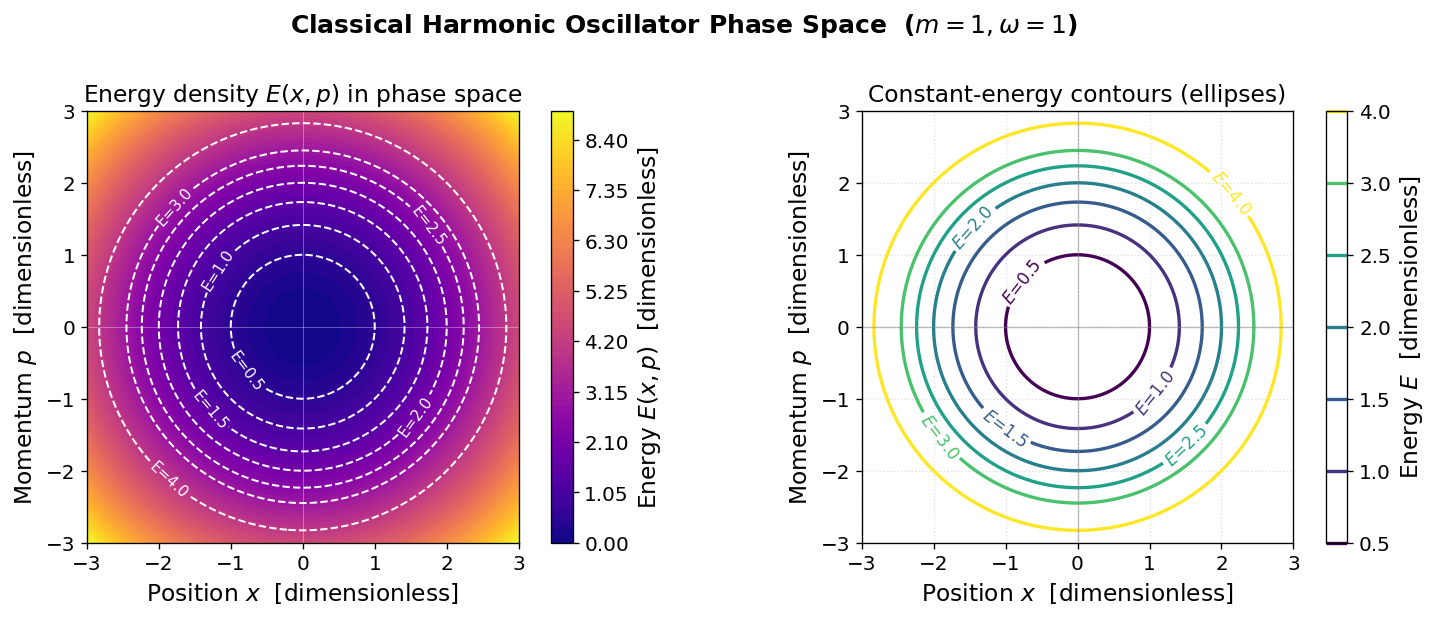


Figure saved: c1_t1_phase_space_energy.png

Caption: Energy E(x,p) = p²/2m + ½mω²x² of the 1D harmonic oscillator plotted
over the (x,p) phase plane (m=ω=1). LEFT: filled density map (plasma colormap)
with constant-energy contours overlaid. RIGHT: selected constant-energy curves
at E = 0.5, 1.0, ..., 4.0. Each contour is an ellipse satisfying x²/(2E/ω²) +
p²/(2E) = 1; for m=ω=1 these reduce to circles. Higher energy → larger ellipse.
The origin (x=p=0) is the unique zero-energy equilibrium point.



In [21]:
# ── Build phase-space grid ────────────────────────────────────────────────────
x_vals = np.linspace(-3, 3, 400)   # position axis
p_vals = np.linspace(-3, 3, 400)   # momentum axis
X, P   = np.meshgrid(x_vals, p_vals)  # 2D grid
E_grid = energy(X, P)                 # evaluate energy on every grid point

# ── Energy levels to draw contours at ────────────────────────────────────────
energy_levels = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: density plot (imshow-style) with contour overlay ---
ax = axes[0]
im = ax.contourf(X, P, E_grid, levels=60, cmap='plasma')  # filled contours
cb = fig.colorbar(im, ax=ax, label='Energy $E(x,p)$  [dimensionless]')

# Overlay selected constant-energy contour lines in white
cs = ax.contour(X, P, E_grid, levels=energy_levels, colors='white',
                linewidths=1.2, linestyles='--')
ax.clabel(cs, fmt='E=%.1f', fontsize=9, inline=True, inline_spacing=4)

ax.set_xlabel('Position $x$  [dimensionless]')
ax.set_ylabel('Momentum $p$  [dimensionless]')
ax.set_title('Energy density $E(x,p)$ in phase space')
ax.set_aspect('equal')   # equal axes → circles (since m=ω=1)
ax.axhline(0, color='white', lw=0.5, alpha=0.4)
ax.axvline(0, color='white', lw=0.5, alpha=0.4)

# --- Right panel: clean contour lines only, color-coded by energy ---
ax2 = axes[1]
cs2 = ax2.contour(X, P, E_grid, levels=energy_levels, cmap='viridis', linewidths=2.0)
cb2 = fig.colorbar(cs2, ax=ax2, label='Energy $E$  [dimensionless]')
ax2.clabel(cs2, fmt='$E$=%.1f', fontsize=10, inline=True)

ax2.set_xlabel('Position $x$  [dimensionless]')
ax2.set_ylabel('Momentum $p$  [dimensionless]')
ax2.set_title('Constant-energy contours (ellipses)')
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax2.axvline(0, color='gray', lw=0.8, alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.4)

fig.suptitle(
    'Classical Harmonic Oscillator Phase Space  ($m=1, \\omega=1$)',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('c1_t1_phase_space_energy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: c1_t1_phase_space_energy.png")
print("""
Caption: Energy E(x,p) = p²/2m + ½mω²x² of the 1D harmonic oscillator plotted
over the (x,p) phase plane (m=ω=1). LEFT: filled density map (plasma colormap)
with constant-energy contours overlaid. RIGHT: selected constant-energy curves
at E = 0.5, 1.0, ..., 4.0. Each contour is an ellipse satisfying x²/(2E/ω²) +
p²/(2E) = 1; for m=ω=1 these reduce to circles. Higher energy → larger ellipse.
The origin (x=p=0) is the unique zero-energy equilibrium point.
""")

### Why are the constant-energy curves ellipses?

Setting $E(x,p) = E_0$ gives:
$$\frac{x^2}{\left(\sqrt{2E_0/m\omega^2}\right)^2} + \frac{p^2}{\left(\sqrt{2mE_0}\right)^2} = 1$$

This is an ellipse with:
- Semi-axis in $x$: $a = \sqrt{2E_0 / m\omega^2}$ — maximum displacement (all potential energy)
- Semi-axis in $p$: $b = \sqrt{2mE_0}$ — maximum momentum (all kinetic energy)

For $m=\omega=1$: $a = b = \sqrt{2E_0}$ → circles.

**Physical interpretation:** Each ellipse is a closed orbit. The system circulates around the origin at constant energy. This is periodic motion — the defining signature of a stable oscillator.

# Component 1 · Task 2 — Classical Harmonic Oscillator: Dynamics and Trajectories
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Solve the classical equations of motion and visualize how trajectories in phase space depend on initial conditions and energy.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

# ── System parameters (same as Task 1, dimensionless units) ──────────────────
m     = 1.0   # mass
omega = 1.0   # angular frequency

# ── Time array: two full oscillation periods ─────────────────────────────────
T_period = 2 * np.pi / omega          # one period
t = np.linspace(0, 2 * T_period, 1000)  # 1000 time steps over 2 periods

print(f"Period T = 2π/ω = {T_period:.4f} (dimensionless)")
print(f"Simulating {len(t)} time steps over 2 full periods.")

Period T = 2π/ω = 6.2832 (dimensionless)
Simulating 1000 time steps over 2 full periods.


## Core functions

We reuse the analytic solution derived in Task 1:
$$x(t) = x_0\cos(\omega t) + \frac{p_0}{m\omega}\sin(\omega t), \qquad p(t) = -m\omega x_0\sin(\omega t) + p_0\cos(\omega t)$$

and the energy function $E = p^2/2m + \frac{1}{2}m\omega^2 x^2$.

In [23]:
def trajectory(t, x0, p0, m=m, omega=omega):
    """
    Analytic phase-space trajectory of the harmonic oscillator.
    Returns arrays x(t) and p(t) for initial conditions (x0, p0).
    """
    x_t = x0 * np.cos(omega * t) + (p0 / (m * omega)) * np.sin(omega * t)
    p_t = -m * omega * x0 * np.sin(omega * t) + p0 * np.cos(omega * t)
    return x_t, p_t

def energy(x, p, m=m, omega=omega):
    """Classical harmonic oscillator energy E(x,p) = p²/2m + ½mω²x²."""
    return p**2 / (2 * m) + 0.5 * m * omega**2 * x**2

print("Functions defined: trajectory(t, x0, p0) and energy(x, p)")

Functions defined: trajectory(t, x0, p0) and energy(x, p)


## Part (a) — Single trajectory

We choose one initial condition $(x_0, p_0) = (1.5,\, 0.5)$ and simulate the full trajectory. 
The initial point is marked with a star; arrows show the direction of motion.

Initial energy E₀ = 1.25000
Energy along trajectory: min=1.25000, max=1.25000
Max drift = 8.88e-16  ✓ conserved


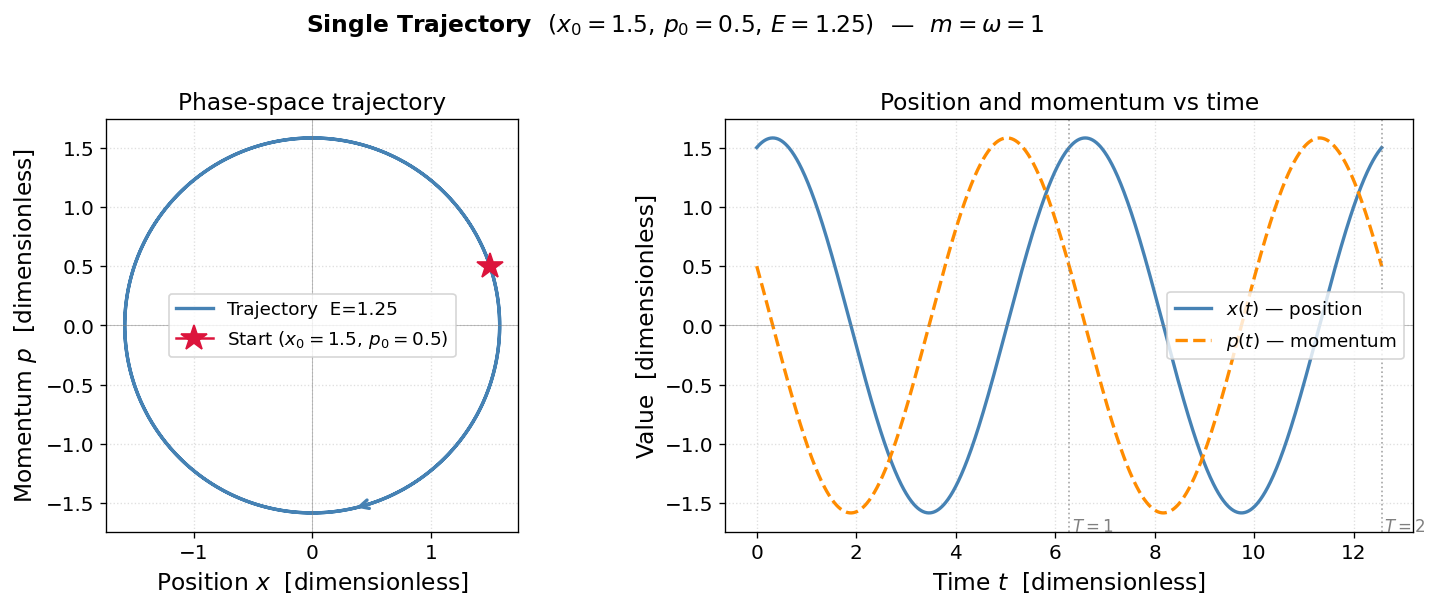


Caption: LEFT — phase-space trajectory of the 1D harmonic oscillator for initial
condition (x₀=1.5, p₀=0.5), energy E=1.25 (m=ω=1). The trajectory is a closed
ellipse (circle for m=ω=1); the red star marks the starting point and the arrow
shows the counter-clockwise direction of motion. RIGHT — x(t) and p(t) plotted
separately vs time. Both are sinusoids with period T=2π/ω≈6.28; momentum lags
position by a quarter period (90°), as expected from the analytic solution.



In [24]:
# ── Initial condition ─────────────────────────────────────────────────────────
x0, p0 = 1.5, 0.5
E0 = energy(x0, p0)

# ── Compute trajectory ────────────────────────────────────────────────────────
x_traj, p_traj = trajectory(t, x0, p0)

# ── Energy conservation check ─────────────────────────────────────────────────
E_along = energy(x_traj, p_traj)
print(f"Initial energy E₀ = {E0:.5f}")
print(f"Energy along trajectory: min={E_along.min():.5f}, max={E_along.max():.5f}")
print(f"Max drift = {(E_along.max() - E_along.min()):.2e}  ✓ conserved")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: phase-space trajectory ---
ax = axes[0]
ax.plot(x_traj, p_traj, color='steelblue', lw=2, label=f'Trajectory  E={E0:.2f}')

# Mark the initial point
ax.plot(x0, p0, marker='*', markersize=16, color='crimson', zorder=5,
        label=f'Start $(x_0={x0},\, p_0={p0})$')

# Add a direction arrow at ~quarter period
idx = len(t) // 8
ax.annotate('', xy=(x_traj[idx+8], p_traj[idx+8]),
            xytext=(x_traj[idx], p_traj[idx]),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))

ax.set_xlabel('Position $x$  [dimensionless]')
ax.set_ylabel('Momentum $p$  [dimensionless]')
ax.set_title('Phase-space trajectory')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()

# --- Right: x(t) and p(t) vs time ---
ax2 = axes[1]
ax2.plot(t, x_traj, color='steelblue', lw=2, label='$x(t)$ — position')
ax2.plot(t, p_traj, color='darkorange', lw=2, linestyle='--', label='$p(t)$ — momentum')
ax2.axhline(0, color='gray', lw=0.6, alpha=0.5)

# Mark period boundaries
for k in [1, 2]:
    ax2.axvline(k * T_period, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax2.text(k * T_period + 0.05, ax2.get_ylim()[0] if ax2.get_ylim()[0] > -3 else -1.6,
             f'$T={k}$', fontsize=10, color='gray')

ax2.set_xlabel('Time $t$  [dimensionless]')
ax2.set_ylabel('Value  [dimensionless]')
ax2.set_title('Position and momentum vs time')
ax2.grid(True, linestyle=':', alpha=0.4)
ax2.legend()

fig.suptitle(
    f'Single Trajectory  $(x_0={x0},\, p_0={p0},\, E={E0:.2f})$  —  $m=\\omega=1$',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('c1_t2_single_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: LEFT — phase-space trajectory of the 1D harmonic oscillator for initial
condition (x₀=1.5, p₀=0.5), energy E=1.25 (m=ω=1). The trajectory is a closed
ellipse (circle for m=ω=1); the red star marks the starting point and the arrow
shows the counter-clockwise direction of motion. RIGHT — x(t) and p(t) plotted
separately vs time. Both are sinusoids with period T=2π/ω≈6.28; momentum lags
position by a quarter period (90°), as expected from the analytic solution.
""")

## Part (b) — Many trajectories: random initial conditions

We sample a set of random initial conditions $(x_0, p_0)$ and plot all trajectories together.
Each trajectory is colored by its initial energy $E_0$.

**What to look for:**
- Trajectories with the same energy trace the same ellipse, just starting at different points on it
- Higher energy → larger ellipse
- No two trajectories with *different* energies ever cross — energy is conserved and each ellipse is its own closed orbit

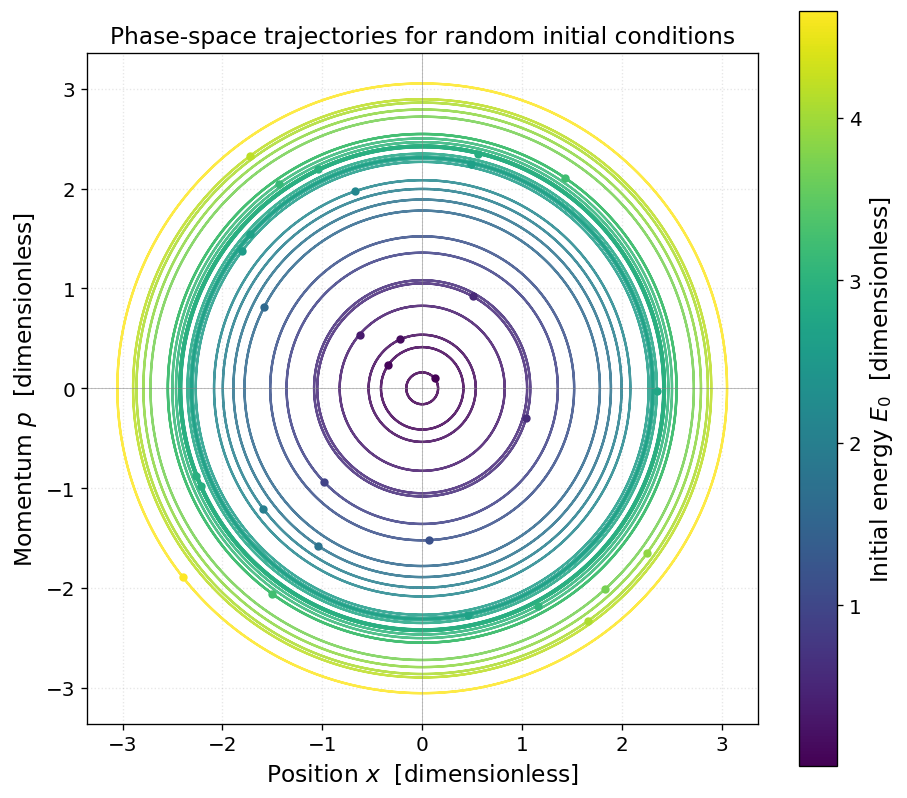

Plotted 30 trajectories.
Energy range: 0.01 to 4.66

Caption: Phase-space trajectories of the 1D harmonic oscillator for 30 random
initial conditions (x₀, p₀) drawn uniformly from [-2.5, 2.5]² (m=ω=1). Each
trajectory is colored by its initial energy E₀ (viridis colormap: dark purple =
low E, yellow = high E). Small circles mark the initial points. All trajectories
are closed ellipses (circles for m=ω=1). Key observations: (1) trajectory shape
is determined entirely by E₀ — same energy gives same ellipse; (2) higher energy
gives a larger ellipse; (3) trajectories with different energies never intersect,
since energy is conserved and each orbit is uniquely determined by E₀.



In [25]:
np.random.seed(42)   # fixed seed for reproducibility

# ── Generate random initial conditions ───────────────────────────────────────
n_traj = 30
x0_vals = np.random.uniform(-2.5, 2.5, n_traj)   # random positions
p0_vals = np.random.uniform(-2.5, 2.5, n_traj)   # random momenta
E0_vals = energy(x0_vals, p0_vals)               # energy of each trajectory

# ── Color-map: map energy to color ───────────────────────────────────────────
E_min, E_max = E0_vals.min(), E0_vals.max()
cmap = cm.viridis
norm = plt.Normalize(vmin=E_min, vmax=E_max)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for x0_i, p0_i, E0_i in zip(x0_vals, p0_vals, E0_vals):
    x_i, p_i = trajectory(t, x0_i, p0_i)   # compute trajectory
    color = cmap(norm(E0_i))                 # color by energy
    ax.plot(x_i, p_i, color=color, lw=1.4, alpha=0.85)
    ax.plot(x0_i, p0_i, 'o', color=color, markersize=4, zorder=5)  # mark start

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Initial energy $E_0$  [dimensionless]')

ax.set_xlabel('Position $x$  [dimensionless]')
ax.set_ylabel('Momentum $p$  [dimensionless]')
ax.set_title('Phase-space trajectories for random initial conditions')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('c1_t2_many_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Plotted {n_traj} trajectories.")
print(f"Energy range: {E_min:.2f} to {E_max:.2f}")
print("""
Caption: Phase-space trajectories of the 1D harmonic oscillator for 30 random
initial conditions (x₀, p₀) drawn uniformly from [-2.5, 2.5]² (m=ω=1). Each
trajectory is colored by its initial energy E₀ (viridis colormap: dark purple =
low E, yellow = high E). Small circles mark the initial points. All trajectories
are closed ellipses (circles for m=ω=1). Key observations: (1) trajectory shape
is determined entirely by E₀ — same energy gives same ellipse; (2) higher energy
gives a larger ellipse; (3) trajectories with different energies never intersect,
since energy is conserved and each orbit is uniquely determined by E₀.
""")

## Summary: what the trajectories tell us

| Observation | Physical meaning |
|---|---|
| All trajectories are closed ellipses | Motion is periodic — the system returns to its starting point every period $T = 2\pi/\omega$ |
| Ellipse size depends only on $E_0$ | Energy is the only conserved quantity; it fully determines the orbit |
| No two trajectories with different $E$ cross | Conservation of energy means each orbit is isolated — the system cannot jump between energy levels classically |
| $x(t)$ and $p(t)$ are sinusoids 90° apart | Position and momentum are in quadrature: when $x$ is maximum, $p=0$, and vice versa |

**Connection to Component 2:** In quantum mechanics, the situation changes dramatically. The system cannot have arbitrary energy — only discrete values $E_n = \hbar\omega(n + \frac{1}{2})$ are allowed. This is the quantum counterpart of the continuous family of ellipses we see here.

# Component 1 · Task 3 — Nonlinear Oscillator: Cosine Potential and Phase Space
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Add a cosine term to the harmonic potential, derive the new equations of motion, and see how the phase-space trajectories change from clean ellipses to more complicated shapes.

**Beginner context:** So far the oscillator has been perfectly harmonic — the restoring force was exactly proportional to $x$, so every trajectory in phase space was a perfect ellipse, no matter the energy. Real systems (and the superconducting qubits we will study in Component 2) are never perfectly harmonic. Here we add a cosine term $-V_0\cos(kx)$ to the potential. This is the same mathematical shape as a **pendulum potential** (gravity acting on a swinging pendulum) and, later, the **Josephson junction potential** in a fluxonium qubit. Understanding this classical model first will make the quantum fluxonium calculation in Component 2 much easier to follow.

## Setup

We reuse the mass $m$ and frequency $\omega$ from Task 1, and introduce two new parameters:
- $V_0$ — sets how strong the cosine term is compared to the harmonic term
- $k$ — sets the spatial period of the cosine ($2\pi/k$)

The new Hamiltonian is
$$H(x,p) = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2 - V_0\cos(kx).$$

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import solve_ivp  # numerical ODE solver (we can no longer use a neat analytic formula)

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11, 'figure.dpi': 120,
})

# System parameters
m     = 1.0   # mass (dimensionless units)
omega = 1.0   # harmonic angular frequency (dimensionless units)
V0    = 1.0   # strength of the cosine nonlinearity (dimensionless units)
k     = 1.0   # spatial frequency of the cosine term (dimensionless units)

def energy_nl(x, p, m=m, omega=omega, V0=V0, k=k):
    """Total energy (Hamiltonian) of the nonlinear oscillator."""
    kinetic   = p**2 / (2 * m)
    potential = 0.5 * m * omega**2 * x**2 - V0 * np.cos(k * x)
    return kinetic + potential

print("Energy function defined: E(x,p) = p^2/2m + 1/2 m w^2 x^2 - V0 cos(kx)")
print(f"Parameters: m={m}, omega={omega}, V0={V0}, k={k}")

Energy function defined: E(x,p) = p^2/2m + 1/2 m w^2 x^2 - V0 cos(kx)
Parameters: m=1.0, omega=1.0, V0=1.0, k=1.0


## (a) Equations of Motion

Hamilton's equations are still $\dot{x} = \partial H/\partial p$ and $\dot{p} = -\partial H/\partial x$. Differentiating our new $H$:

$$\dot{x} = \frac{\partial H}{\partial p} = \frac{p}{m}$$

$$\dot{p} = -\frac{\partial H}{\partial x} = -m\omega^2 x - V_0 k \sin(kx)$$

**What changed:** the harmonic force $-m\omega^2 x$ is still there, but there is a brand-new term $-V_0 k\sin(kx)$ coming from differentiating the cosine potential. For *small* $x$, $\sin(kx)\approx kx$, so this new term looks like $-V_0 k^2 x$ — it just adds to (or subtracts from) the harmonic restoring force, slightly shifting the effective frequency. But for *large* $x$ (large-amplitude motion), $\sin(kx)$ saturates and eventually reverses sign, so the restoring force is no longer proportional to $x$. This is exactly what "nonlinear" means: the force law bends away from a straight line. Combining the two equations gives a single second-order equation for $x(t)$:

$$\ddot{x} = -\omega^2 x - \frac{V_0 k}{m}\sin(kx),$$

which is the same form as the equation for a **pendulum** with an extra harmonic term. There is no simple closed-form solution like the $\cos(\omega t)$ we had before, so from here on we integrate the equations of motion **numerically** using `scipy.integrate.solve_ivp`.

In [27]:
def eom_nl(t, y, m=m, omega=omega, V0=V0, k=k):
    """
    Right-hand side of Hamilton's equations for the nonlinear oscillator.
    y = [x, p]. Returns [dx/dt, dp/dt].
    """
    x, p = y
    xdot = p / m
    pdot = -m * omega**2 * x - V0 * k * np.sin(k * x)
    return [xdot, pdot]

# Sanity check: does our formula for pdot match -dE/dx computed numerically?
# This is good practice any time you hand-derive a force: check it against a
# finite-difference derivative of the energy before trusting the simulation.
x_test, p_test = 0.7, 0.0
dx = 1e-6
dEdx_numeric = (energy_nl(x_test + dx, p_test) - energy_nl(x_test - dx, p_test)) / (2 * dx)
pdot_analytic = eom_nl(0, [x_test, p_test])[1]
print(f"-dE/dx (numerical)    = {-dEdx_numeric:.6f}")
print(f"pdot   (from formula) = {pdot_analytic:.6f}")
print("Match!" if np.isclose(-dEdx_numeric, pdot_analytic, atol=1e-4) else "MISMATCH - check derivation")

-dE/dx (numerical)    = -1.344218
pdot   (from formula) = -1.344218
Match!


## (b) Trajectories at Several Initial Energies

To simulate at a chosen energy $E_0$, we need a starting point $(x_0, p_0)$ with $E(x_0,p_0)=E_0$. The easiest choice is to start at the bottom of the well, $x_0 = 0$ (where $\cos(0)=1$), so that
$$E_0 = \frac{p_0^2}{2m} - V_0 \quad\Longrightarrow\quad p_0 = \sqrt{2m(E_0+V_0)}.$$
This only requires $E_0 > -V_0$ (the minimum possible energy), which is always satisfied for the energies we pick below.

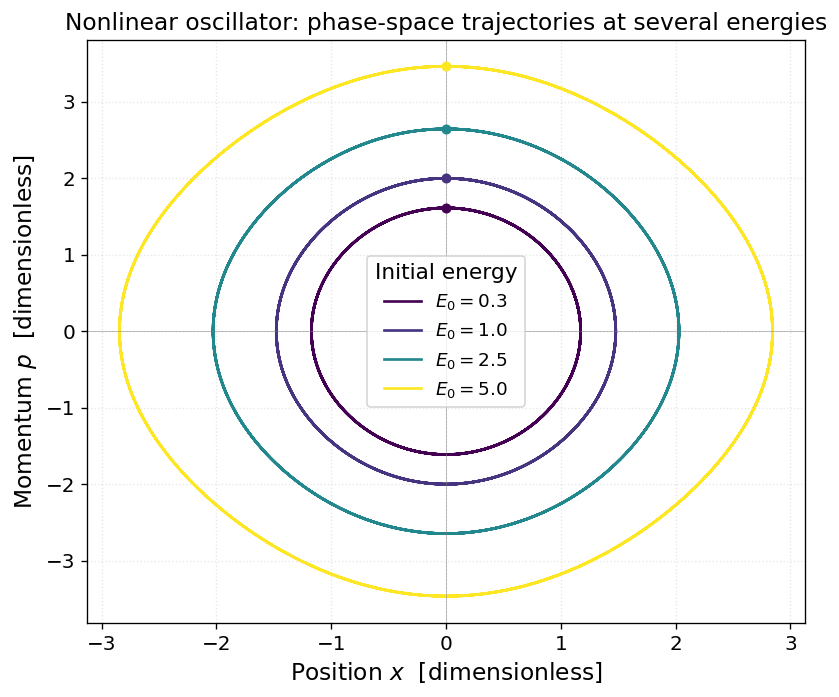


Caption: Phase-space trajectories of the nonlinear (cosine-potential) oscillator
for four initial energies E0, all starting at x=0 (colored dots) with matching
momentum p0 = sqrt(2m(E0+V0)). At low E0 the orbit is nearly a perfect ellipse,
just like the pure harmonic oscillator, because the motion stays close to x=0
where the cosine term is well approximated by a parabola. At higher E0 the orbit
visibly departs from an ellipse - it flattens and develops a more boxy, asymmetric
shape - because the trajectory now explores regions of x where sin(kx) deviates
significantly from kx, i.e. where the nonlinearity matters.



In [28]:
t_span = (0, 25)                      # simulate from t=0 to t=25 (dimensionless time)
t_eval = np.linspace(*t_span, 3000)    # times at which we want the solution reported

E0_list = [0.3, 1.0, 2.5, 5.0]          # a range of initial energies to compare
cmap = cm.viridis
norm = plt.Normalize(min(E0_list), max(E0_list))

fig, ax = plt.subplots(figsize=(7, 6))
for E0 in E0_list:
    p0 = np.sqrt(2 * m * (E0 + V0))     # initial momentum that gives this energy at x0=0
    sol = solve_ivp(eom_nl, t_span, [0.0, p0], t_eval=t_eval, rtol=1e-9, atol=1e-9)
    x_t, p_t = sol.y
    ax.plot(x_t, p_t, color=cmap(norm(E0)), lw=1.6, label=f"$E_0={E0}$")
    ax.plot(0, p0, 'o', color=cmap(norm(E0)), ms=5, zorder=5)  # mark the starting point

ax.set_xlabel("Position $x$  [dimensionless]")
ax.set_ylabel("Momentum $p$  [dimensionless]")
ax.set_title("Nonlinear oscillator: phase-space trajectories at several energies")
ax.legend(title="Initial energy")
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('c1_t3_energy_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: Phase-space trajectories of the nonlinear (cosine-potential) oscillator
for four initial energies E0, all starting at x=0 (colored dots) with matching
momentum p0 = sqrt(2m(E0+V0)). At low E0 the orbit is nearly a perfect ellipse,
just like the pure harmonic oscillator, because the motion stays close to x=0
where the cosine term is well approximated by a parabola. At higher E0 the orbit
visibly departs from an ellipse - it flattens and develops a more boxy, asymmetric
shape - because the trajectory now explores regions of x where sin(kx) deviates
significantly from kx, i.e. where the nonlinearity matters.
""")

## (c) A Band of Trajectories Around a Reference Energy

Now, instead of picking one $(x_0,p_0)$ per energy, we scatter many random initial conditions and **keep only the ones whose energy falls inside a narrow band** $[E_{\rm ref}-\Delta E,\ E_{\rm ref}+\Delta E]$. This technique is called **rejection sampling**: draw a random candidate, compute a property of interest (here, the energy), and keep the candidate only if that property satisfies our condition. It is a simple, general-purpose way to sample from a constrained region without solving equations by hand.

Kept 25 initial conditions out of 208 random draws (acceptance rate 12.02%).


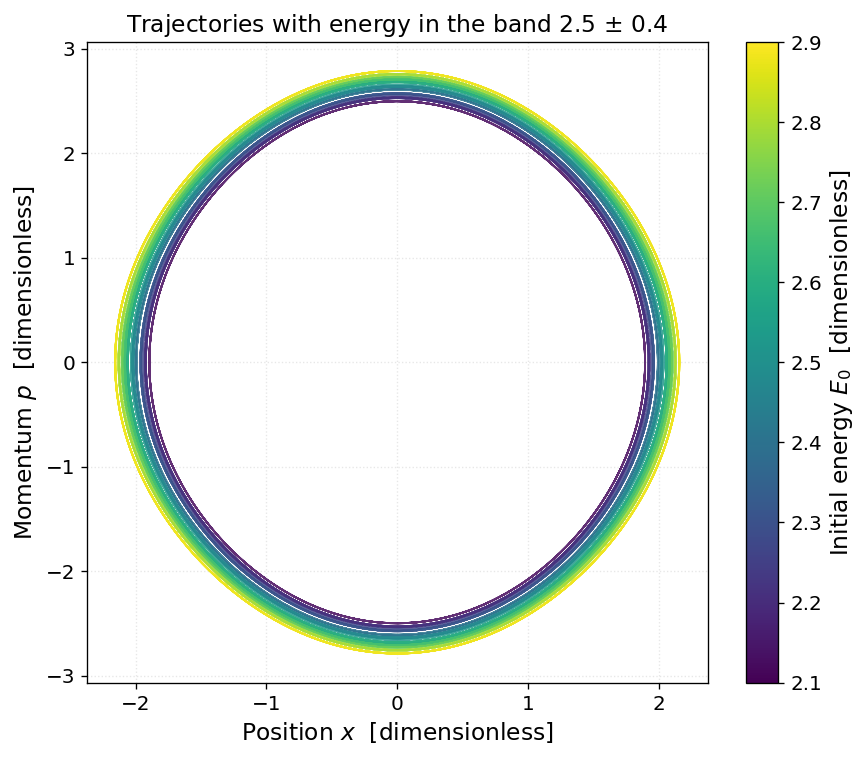


Caption: Phase-space trajectories whose initial energies all lie within a narrow
band Eref +/- dE = 2.5 +/- 0.4, obtained by rejection-sampling random (x0, p0)
pairs. Even though every trajectory starts with almost the same energy, their
shapes and starting locations differ, because (unlike the pure harmonic case)
energy alone no longer fixes a unique ellipse - the cosine term makes the
constant-energy contour a more complicated curve, and different starting
locations along that curve trace out visually different-looking paths.



In [29]:
np.random.seed(0)

Eref, dE = 2.5, 0.4           # reference energy and half-width of the energy band
n_target = 25                  # how many trajectories we want in the band

x0_band, p0_band, E0_band = [], [], []
attempts = 0
while len(x0_band) < n_target and attempts < 200_000:
    attempts += 1
    x0_try = np.random.uniform(-3, 3)
    p0_try = np.random.uniform(-3, 3)
    E0_try = energy_nl(x0_try, p0_try)
    if Eref - dE <= E0_try <= Eref + dE:      # keep only if inside the energy band
        x0_band.append(x0_try)
        p0_band.append(p0_try)
        E0_band.append(E0_try)

print(f"Kept {len(x0_band)} initial conditions out of {attempts} random draws "
      f"(acceptance rate {100*len(x0_band)/attempts:.2f}%).")

# Simulate and plot each trajectory, colored by its own energy
fig, ax = plt.subplots(figsize=(7.5, 6.5))
norm_band = plt.Normalize(Eref - dE, Eref + dE)
for x0_i, p0_i, E0_i in zip(x0_band, p0_band, E0_band):
    sol = solve_ivp(eom_nl, t_span, [x0_i, p0_i], t_eval=t_eval, rtol=1e-9, atol=1e-9)
    ax.plot(sol.y[0], sol.y[1], color=cmap(norm_band(E0_i)), lw=1.1, alpha=0.85)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_band)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Initial energy $E_0$  [dimensionless]")
ax.set_xlabel("Position $x$  [dimensionless]")
ax.set_ylabel("Momentum $p$  [dimensionless]")
ax.set_title(f"Trajectories with energy in the band {Eref} $\pm$ {dE}")
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('c1_t3_energy_band.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: Phase-space trajectories whose initial energies all lie within a narrow
band Eref +/- dE = 2.5 +/- 0.4, obtained by rejection-sampling random (x0, p0)
pairs. Even though every trajectory starts with almost the same energy, their
shapes and starting locations differ, because (unlike the pure harmonic case)
energy alone no longer fixes a unique ellipse - the cosine term makes the
constant-energy contour a more complicated curve, and different starting
locations along that curve trace out visually different-looking paths.
""")

# Component 1 · Task 4 — Two Coupled Oscillators: Momentum Coupling and Poincaré Maps
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Extend Task 3 to *two* nonlinear oscillators that are coupled through their momenta, look at the resulting 4-dimensional phase space through 2D "slices," and use a Poincaré map to see whether the motion is regular or chaotic.

**Beginner context:** Real quantum processors are built from many coupled qubits, not a single isolated one. Before jumping to the quantum case, it is very useful to first understand what coupling *classically* does to phase space. With one oscillator, phase space is a 2D plane $(x,p)$ and we can see the whole thing on one plot. With two oscillators, phase space is 4-dimensional $(x_1,p_1,x_2,p_2)$ — we can no longer see it all at once, so we will look at 2D "shadows" (projections) of it, and use a technique called a **Poincaré section** to compress the long-time behavior into a single 2D picture.

## Setup

Each oscillator has the same cosine-potential form as Task 3, and the two oscillators are linked by a term $\lambda\, p_1 p_2$ that couples their momenta:

$$H = \sum_{i=1}^{2}\left[\frac{p_i^2}{2m} + \frac{1}{2}m\omega_i^2 x_i^2 - V_0\cos(kx_i)\right] + \lambda\, p_1 p_2$$

We give the two oscillators slightly different frequencies $\omega_1 \ne \omega_2$ so that their uncoupled motion is not perfectly synchronized — this makes the effects of coupling easier to see.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10, 'figure.dpi': 120,
})

# System parameters (reusing the single-oscillator nonlinearity from Task 3)
m       = 1.0    # mass, shared by both oscillators (dimensionless units)
omega1  = 1.0    # angular frequency of oscillator 1 (dimensionless units)
omega2  = 1.3    # angular frequency of oscillator 2, deliberately different from omega1
V0      = 1.5    # cosine-potential strength, shared by both oscillators (dimensionless units)
k       = 1.0    # cosine spatial frequency, shared by both oscillators (dimensionless units)
lam     = 0.3    # momentum-momentum coupling strength (dimensionless units)

def energy_coupled(x1, p1, x2, p2, m=m, omega1=omega1, omega2=omega2, V0=V0, k=k, lam=lam):
    """Total energy of the two coupled nonlinear oscillators."""
    e1 = p1**2 / (2 * m) + 0.5 * m * omega1**2 * x1**2 - V0 * np.cos(k * x1)
    e2 = p2**2 / (2 * m) + 0.5 * m * omega2**2 * x2**2 - V0 * np.cos(k * x2)
    coupling = lam * p1 * p2
    return e1 + e2 + coupling

print("Energy function defined for the two coupled oscillators.")
print(f"Parameters: m={m}, omega1={omega1}, omega2={omega2}, V0={V0}, k={k}, lambda={lam}")

Energy function defined for the two coupled oscillators.
Parameters: m=1.0, omega1=1.0, omega2=1.3, V0=1.5, k=1.0, lambda=0.3


## (a) Equations of Motion

We apply Hamilton's equations $\dot{x}_i = \partial H/\partial p_i$ and $\dot{p}_i = -\partial H/\partial x_i$ to each variable in turn. The only new feature compared to Task 3 is the coupling term $\lambda p_1 p_2$, which depends on *both* momenta at once.

$$\dot{x}_1 = \frac{\partial H}{\partial p_1} = \frac{p_1}{m} + \lambda p_2 \qquad\qquad \dot{p}_1 = -\frac{\partial H}{\partial x_1} = -m\omega_1^2 x_1 - V_0 k\sin(kx_1)$$

$$\dot{x}_2 = \frac{\partial H}{\partial p_2} = \frac{p_2}{m} + \lambda p_1 \qquad\qquad \dot{p}_2 = -\frac{\partial H}{\partial x_2} = -m\omega_2^2 x_2 - V_0 k\sin(kx_2)$$

**Notice:** the momentum equations $\dot p_1,\dot p_2$ look exactly like two independent Task-3 oscillators — the coupling term $\lambda p_1 p_2$ does not depend on $x_1$ or $x_2$, so it contributes nothing to $-\partial H/\partial x_i$. Instead, the coupling shows up entirely in the *position* equations: each oscillator's velocity $\dot x_i$ now depends on the *other* oscillator's momentum. Physically, this means giving oscillator 2 some momentum will drag oscillator 1's position along with it, and vice versa — the two oscillators can exchange motion even though their potential-energy terms are completely separate.

In [31]:
def eom_coupled(t, y, m=m, omega1=omega1, omega2=omega2, V0=V0, k=k, lam=lam):
    """
    Right-hand side of Hamilton's equations for the two coupled oscillators.
    y = [x1, p1, x2, p2]. Returns [dx1/dt, dp1/dt, dx2/dt, dp2/dt].
    """
    x1, p1, x2, p2 = y
    x1dot = p1 / m + lam * p2
    p1dot = -m * omega1**2 * x1 - V0 * k * np.sin(k * x1)
    x2dot = p2 / m + lam * p1
    p2dot = -m * omega2**2 * x2 - V0 * k * np.sin(k * x2)
    return [x1dot, p1dot, x2dot, p2dot]

# Sanity check against a finite-difference gradient of the energy, same idea as Task 3
y_test = [0.4, 0.2, -0.3, 0.15]
dx = 1e-6
def partial_energy(idx, y, dx=dx):
    y_plus, y_minus = list(y), list(y)
    y_plus[idx] += dx
    y_minus[idx] -= dx
    return (energy_coupled(*y_plus) - energy_coupled(*y_minus)) / (2 * dx)

rhs_numeric  = [partial_energy(1, y_test), -partial_energy(0, y_test),
                partial_energy(3, y_test), -partial_energy(2, y_test)]
rhs_analytic = eom_coupled(0, y_test)
print("Numeric :", np.round(rhs_numeric, 6))
print("Analytic:", np.round(rhs_analytic, 6))
print("Match!" if np.allclose(rhs_numeric, rhs_analytic, atol=1e-4) else "MISMATCH - check derivation")

Numeric : [ 0.245    -0.984128  0.21      0.95028 ]
Analytic: [ 0.245    -0.984128  0.21      0.95028 ]
Match!


## (b) Four Phase-Space Projections at Fixed Energy

The full phase space has 4 dimensions $(x_1,p_1,x_2,p_2)$, which we cannot plot directly. Instead we look at the four natural 2D "shadows": $(x_1,p_1)$, $(x_2,p_2)$, $(x_1,x_2)$, and $(p_1,p_2)$.

To get a *fixed* initial energy $E_0$ in a simple, reproducible way, we start both oscillators at rest ($p_{1,0}=p_{2,0}=0$) and displaced by the same amount, $x_{1,0}=x_{2,0}=A$. Sweeping the amplitude $A$ sweeps the energy $E_0$.

A =  0.6  ->  E0 = -1.992
A =  1.2  ->  E0 = 0.850
A =  1.8  ->  E0 = 5.039
A =  2.4  ->  E0 = 9.959


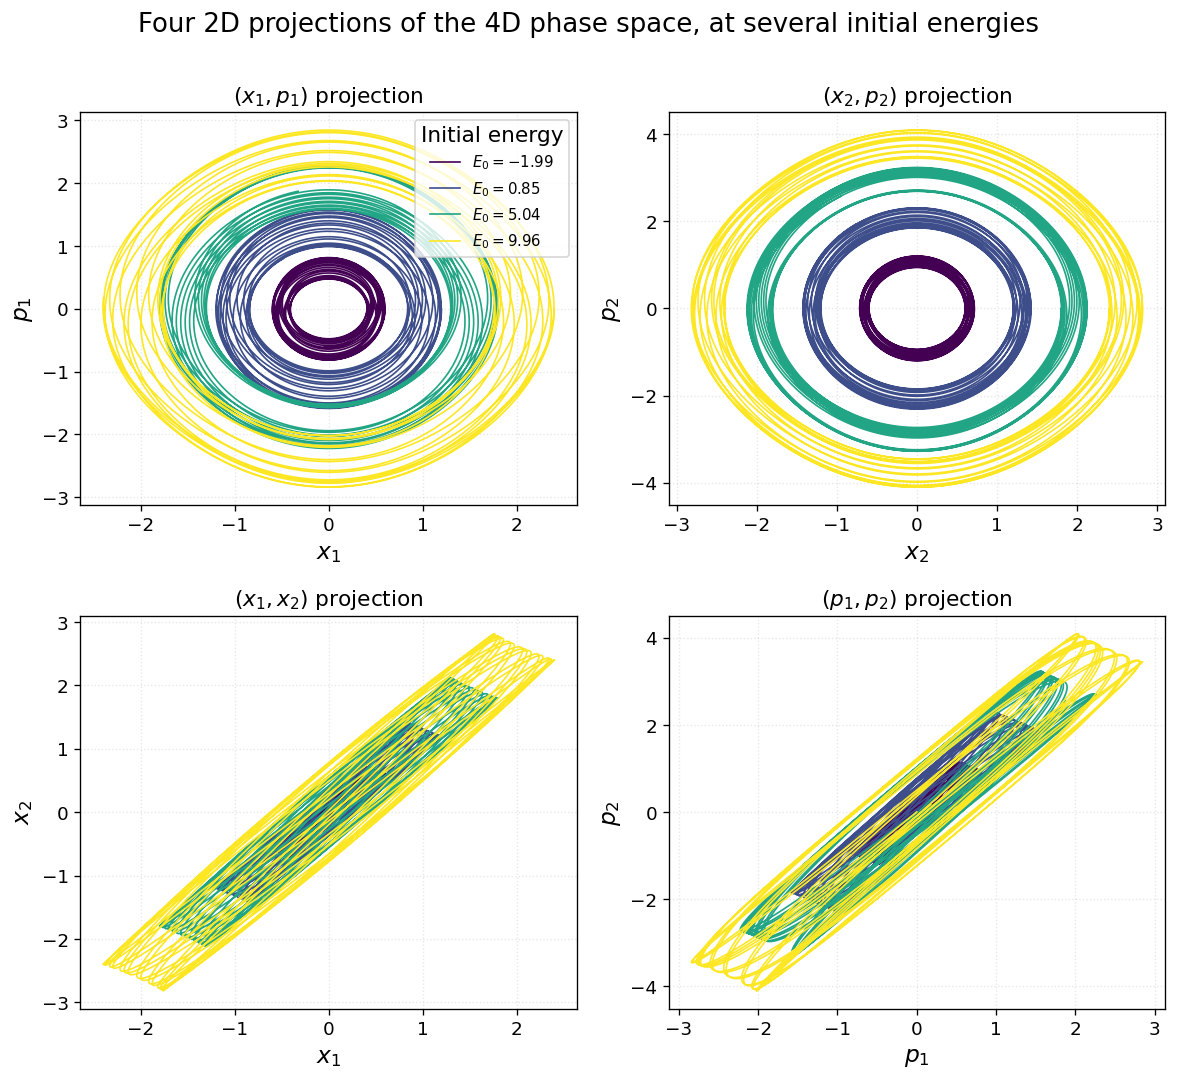


Caption: The four natural 2D projections of the 4D phase space (x1,p1,x2,p2),
shown for four initial energies E0 (all trajectories start at rest, displaced
symmetrically: x1=x2=A, p1=p2=0). At low E0 the (x1,p1) and (x2,p2) projections
still look like the closed, near-elliptical loops we saw for a single nonlinear
oscillator, and the (x1,x2) / (p1,p2) projections are simple closed curves too,
reflecting near-independent, regular motion. As E0 increases the loops in every
panel become visibly thicker, more structured, or less closed - a sign that the
coupling lambda*p1*p2 is exchanging energy between the two oscillators more
effectively at higher amplitude, where the cosine nonlinearity is stronger.



In [32]:
def energy_at_amplitude(A):
    """Energy when both oscillators start at rest, displaced by the same amount A."""
    return energy_coupled(A, 0.0, A, 0.0)

A_list = [0.6, 1.2, 1.8, 2.4]                     # amplitudes to scan
E0_list_coupled = [energy_at_amplitude(A) for A in A_list]
for A, E0 in zip(A_list, E0_list_coupled):
    print(f"A = {A:>4}  ->  E0 = {E0:.3f}")

t_span_c = (0, 60)
t_eval_c = np.linspace(*t_span_c, 6000)

cmap = cm.viridis
norm_c = plt.Normalize(min(E0_list_coupled), max(E0_list_coupled))

fig, axs = plt.subplots(2, 2, figsize=(10, 9))
for A, E0 in zip(A_list, E0_list_coupled):
    sol = solve_ivp(eom_coupled, t_span_c, [A, 0.0, A, 0.0], t_eval=t_eval_c, rtol=1e-9, atol=1e-9)
    x1, p1, x2, p2 = sol.y
    color = cmap(norm_c(E0))
    axs[0, 0].plot(x1, p1, color=color, lw=1.0, label=f"$E_0={E0:.2f}$")
    axs[0, 1].plot(x2, p2, color=color, lw=1.0)
    axs[1, 0].plot(x1, x2, color=color, lw=1.0)
    axs[1, 1].plot(p1, p2, color=color, lw=1.0)

axs[0, 0].set_xlabel("$x_1$"); axs[0, 0].set_ylabel("$p_1$"); axs[0, 0].set_title("$(x_1, p_1)$ projection")
axs[0, 1].set_xlabel("$x_2$"); axs[0, 1].set_ylabel("$p_2$"); axs[0, 1].set_title("$(x_2, p_2)$ projection")
axs[1, 0].set_xlabel("$x_1$"); axs[1, 0].set_ylabel("$x_2$"); axs[1, 0].set_title("$(x_1, x_2)$ projection")
axs[1, 1].set_xlabel("$p_1$"); axs[1, 1].set_ylabel("$p_2$"); axs[1, 1].set_title("$(p_1, p_2)$ projection")
for a in axs.flat:
    a.grid(True, linestyle=':', alpha=0.3)
axs[0, 0].legend(fontsize=9, title="Initial energy")
fig.suptitle("Four 2D projections of the 4D phase space, at several initial energies", y=1.00)
plt.tight_layout()
plt.savefig('c1_t4_projections.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: The four natural 2D projections of the 4D phase space (x1,p1,x2,p2),
shown for four initial energies E0 (all trajectories start at rest, displaced
symmetrically: x1=x2=A, p1=p2=0). At low E0 the (x1,p1) and (x2,p2) projections
still look like the closed, near-elliptical loops we saw for a single nonlinear
oscillator, and the (x1,x2) / (p1,p2) projections are simple closed curves too,
reflecting near-independent, regular motion. As E0 increases the loops in every
panel become visibly thicker, more structured, or less closed - a sign that the
coupling lambda*p1*p2 is exchanging energy between the two oscillators more
effectively at higher amplitude, where the cosine nonlinearity is stronger.
""")

## (c) A Band of Trajectories Around a Reference Energy

Just like in Task 3(c), we now sample many random initial conditions in all four variables $(x_1,p_1,x_2,p_2)$ and keep only the ones whose total energy falls in a chosen band $[E_{\rm ref}-\Delta E,\ E_{\rm ref}+\Delta E]$. We then look separately at the $(x_1,p_1)$ and $(x_2,p_2)$ projections, coloring each trajectory by its initial energy.

Kept 20 initial conditions out of 179 random draws (acceptance rate 11.173%).


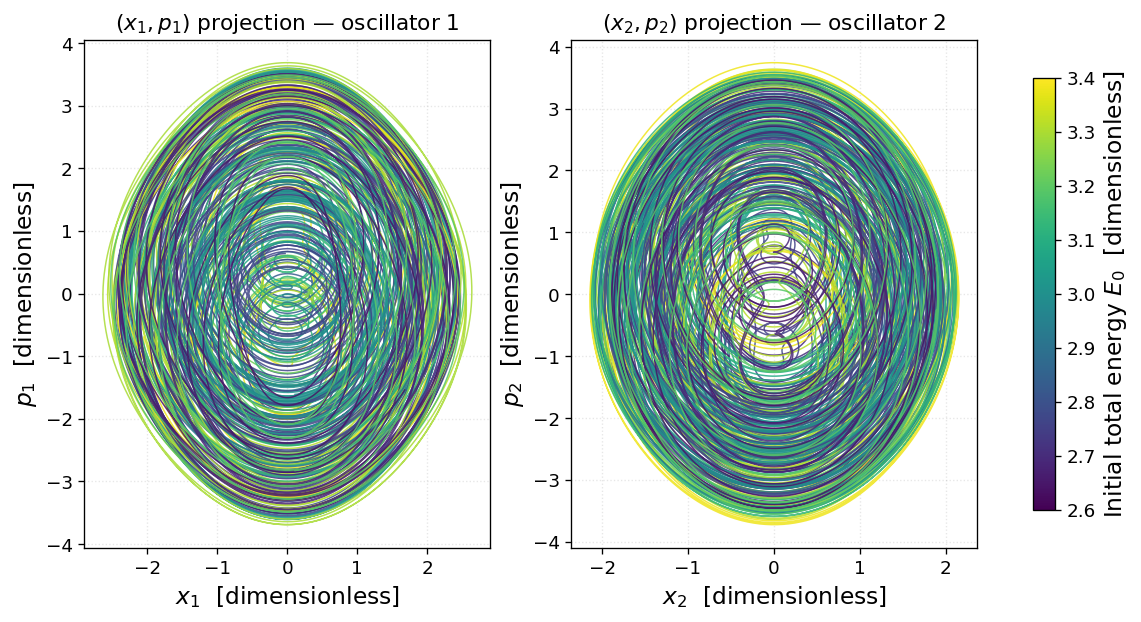


Caption: (x1,p1) and (x2,p2) projections for 20 trajectories whose TOTAL energy
(summed over both oscillators plus the coupling term) lies in a narrow band
around Eref=3.0. Because the energy band constrains only the sum, individual
oscillators can carry very different shares of that energy, which is why the
orbits in each panel still vary noticeably in size even though every trajectory
has almost the same total energy - a direct visual signature of energy being
exchanged between (and shared unevenly across) the two coupled oscillators.



In [33]:
np.random.seed(1)

Eref_c, dE_c = 3.0, 0.4
n_target_c = 20

samples = []
attempts = 0
while len(samples) < n_target_c and attempts < 500_000:
    attempts += 1
    cand = np.random.uniform(-2.5, 2.5, size=4)      # random (x1, p1, x2, p2)
    E_cand = energy_coupled(*cand)
    if Eref_c - dE_c <= E_cand <= Eref_c + dE_c:
        samples.append((cand, E_cand))

print(f"Kept {len(samples)} initial conditions out of {attempts} random draws "
      f"(acceptance rate {100*len(samples)/attempts:.3f}%).")

norm_band_c = plt.Normalize(Eref_c - dE_c, Eref_c + dE_c)
fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))

for cand, E_cand in samples:
    sol = solve_ivp(eom_coupled, t_span_c, cand, t_eval=t_eval_c, rtol=1e-9, atol=1e-9)
    x1, p1, x2, p2 = sol.y
    color = cmap(norm_band_c(E_cand))
    axs[0].plot(x1, p1, color=color, lw=0.9, alpha=0.85)
    axs[1].plot(x2, p2, color=color, lw=0.9, alpha=0.85)

for a, xi, pi, ttl in zip(axs, ["x_1", "x_2"], ["p_1", "p_2"], ["oscillator 1", "oscillator 2"]):
    a.set_xlabel(f"${xi}$  [dimensionless]")
    a.set_ylabel(f"${pi}$  [dimensionless]")
    a.set_title(f"$({xi}, {pi})$ projection — {ttl}")
    a.grid(True, linestyle=':', alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_band_c)
sm.set_array([])
fig.colorbar(sm, ax=axs, label="Initial total energy $E_0$  [dimensionless]", shrink=0.85)
plt.savefig('c1_t4_energy_band.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: (x1,p1) and (x2,p2) projections for 20 trajectories whose TOTAL energy
(summed over both oscillators plus the coupling term) lies in a narrow band
around Eref=3.0. Because the energy band constrains only the sum, individual
oscillators can carry very different shares of that energy, which is why the
orbits in each panel still vary noticeably in size even though every trajectory
has almost the same total energy - a direct visual signature of energy being
exchanged between (and shared unevenly across) the two coupled oscillators.
""")

## (d) Poincaré Maps

**What is a Poincaré map, in plain language?** Imagine standing at one fixed "gate" in phase space and taking a snapshot every time the system passes through that gate (always crossing in the same direction). Instead of trying to look at an entire, tangled 4D trajectory over a long time, we reduce it to a sequence of points on a 2D plane. If the motion is simple ("regular"), those points trace out a smooth curve or a small number of them. If the motion is complicated ("chaotic"), the points scatter over a 2D region with no obvious pattern.

Here we choose the "gate" (surface of section) to be $x_2 = 0$, and we only record a point when the system is crossing with $p_2 > 0$ (moving in one consistent direction), so each crossing is unambiguous. Each recorded point is the pair $(x_1, p_1)$ at that instant.

In [ ]:
def section_event(t, y):
    """Event function: triggers when x2 crosses zero. solve_ivp finds the times where this hits 0."""
    return y[2]                 # this is x2
section_event.direction = 1      # only trigger on upward crossings (x2 going from - to +, i.e. p2 > 0 here)

def poincare_section(y0, t_max):
    """
    Integrate the coupled system for a long time and record (x1, p1) every time
    the trajectory crosses the surface x2 = 0 with p2 > 0.
    """
    sol = solve_ivp(eom_coupled, (0, t_max), y0, max_step=0.05,
                     events=section_event, rtol=1e-10, atol=1e-10)
    crossings = sol.y_events[0]           # shape (n_crossings, 4): each row is [x1,p1,x2,p2] at a crossing
    keep = crossings[:, 3] > 0            # double-check p2 > 0 (should already be true given direction=1)
    return crossings[keep, 0], crossings[keep, 1]   # return x1, p1 at each crossing

# Two different initial conditions -> two different total energies, for comparison
ic_low  = [0.3, 0.2, 0.2, 0.1]
ic_high = [1.8, 0.5, 1.5, 0.3]
E_low  = energy_coupled(*ic_low)
E_high = energy_coupled(*ic_high)

x1_low,  p1_low  = poincare_section(ic_low,  t_max=4000)
x1_high, p1_high = poincare_section(ic_high, t_max=4000)

fig, axs = plt.subplots(1, 2, figsize=(11, 5.2))
axs[0].plot(x1_low, p1_low, '.', ms=2, color='#2E5EAA')
axs[0].set_title(f"Poincare section, $E_0={E_low:.2f}$  ({len(x1_low)} crossings)")
axs[1].plot(x1_high, p1_high, '.', ms=2, color='#C0392B')
axs[1].set_title(f"Poincare section, $E_0={E_high:.2f}$  ({len(x1_high)} crossings)")
for a in axs:
    a.set_xlabel("$x_1$  [dimensionless]")
    a.set_ylabel("$p_1$  [dimensionless]")
    a.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('c1_t4_poincare.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: Poincare sections (surface x2=0, p2>0) for two initial energies. Each
point is one crossing of the section by the same long trajectory. Smooth,
one-dimensional-looking curves of points indicate regular (quasiperiodic)
motion confined to a torus in phase space; a diffuse, area-filling scatter of
points instead indicates chaotic motion, where nearby trajectories separate
exponentially fast and no longer trace out a simple curve.
""")

### Open questions for discussion

Looking at the two panels above:

- Do the points in the lower-energy panel trace out a smooth, closed-looking curve (or a small set of them)? That pattern is the signature of **regular** motion — the orbit stays confined to a smooth surface (a torus) in the full 4D phase space, and the Poincaré map is just a 1D slice of that torus.
- Does the higher-energy panel look more scattered, filling in a 2D patch rather than tracing a curve? That is the signature of **chaotic** motion, where the momentum coupling $\lambda p_1 p_2$ combined with the cosine nonlinearity can pump energy back and forth between the oscillators in a way that is extremely sensitive to the initial conditions.
- Try re-running part (d) with a larger coupling `lam` or a larger `V0`, or scanning several more initial conditions. Does the amount of scatter increase smoothly with energy, or does it appear suddenly above some threshold? This is exactly the kind of open question you should bring to a group meeting: state what you tried, show the figure, and describe what you don't yet understand.